## **Deep Learning Module End — Diabetes Progression Prediction**

In [1]:
#Code:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
#load dataset

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (442, 10)
Target shape: (442,)


In [26]:
print("Feature Names:")
print(diabetes.feature_names)

Feature Names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [5]:
df = pd.DataFrame(X, columns=df.feature_names)
df["target"] = y

df.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [7]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [8]:
#Missing values

print("Missing values:")
print(df.isnull().sum())

Missing values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [10]:
#Duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


***Exploratory Data Analysis***

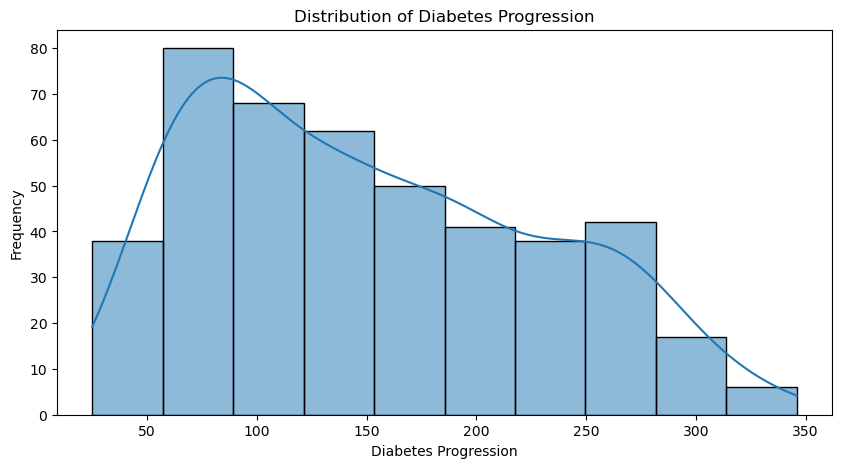

In [18]:
#To identify distribution

plt.figure(figsize=(10, 5))

sns.histplot(df["target"], kde=True)

plt.title("Distribution of Diabetes Progression")
plt.xlabel("Diabetes Progression")
plt.ylabel("Frequency")
plt.show()

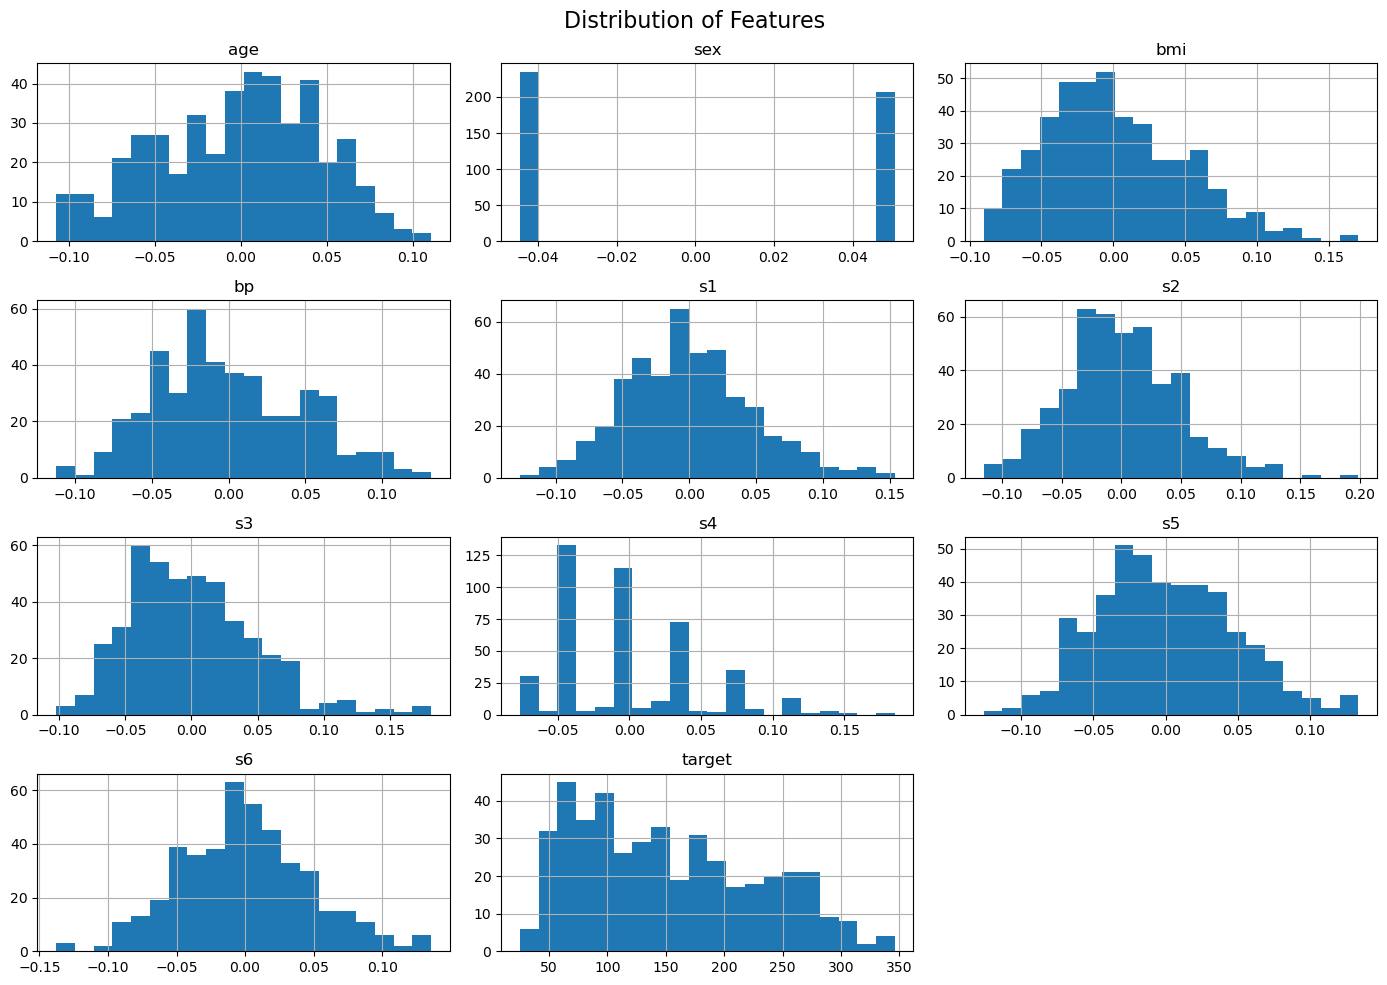

In [21]:
#To find distribution of numerical features

df.hist(figsize=(14, 10), bins=20)

plt.suptitle("Distribution of Features", fontsize=16)
plt.tight_layout()
plt.show()

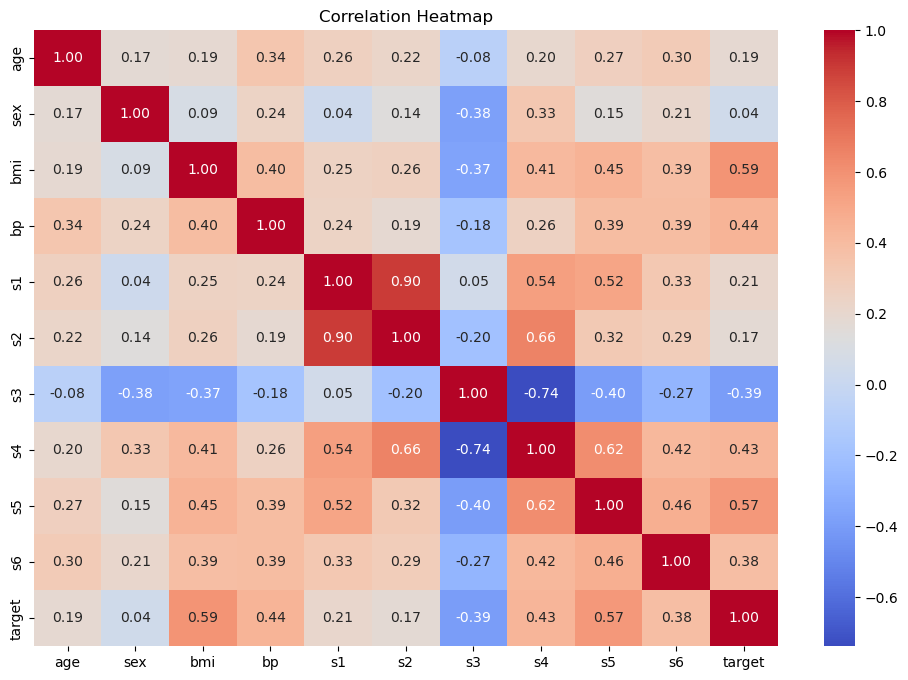

In [22]:
#Correlation analysis

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

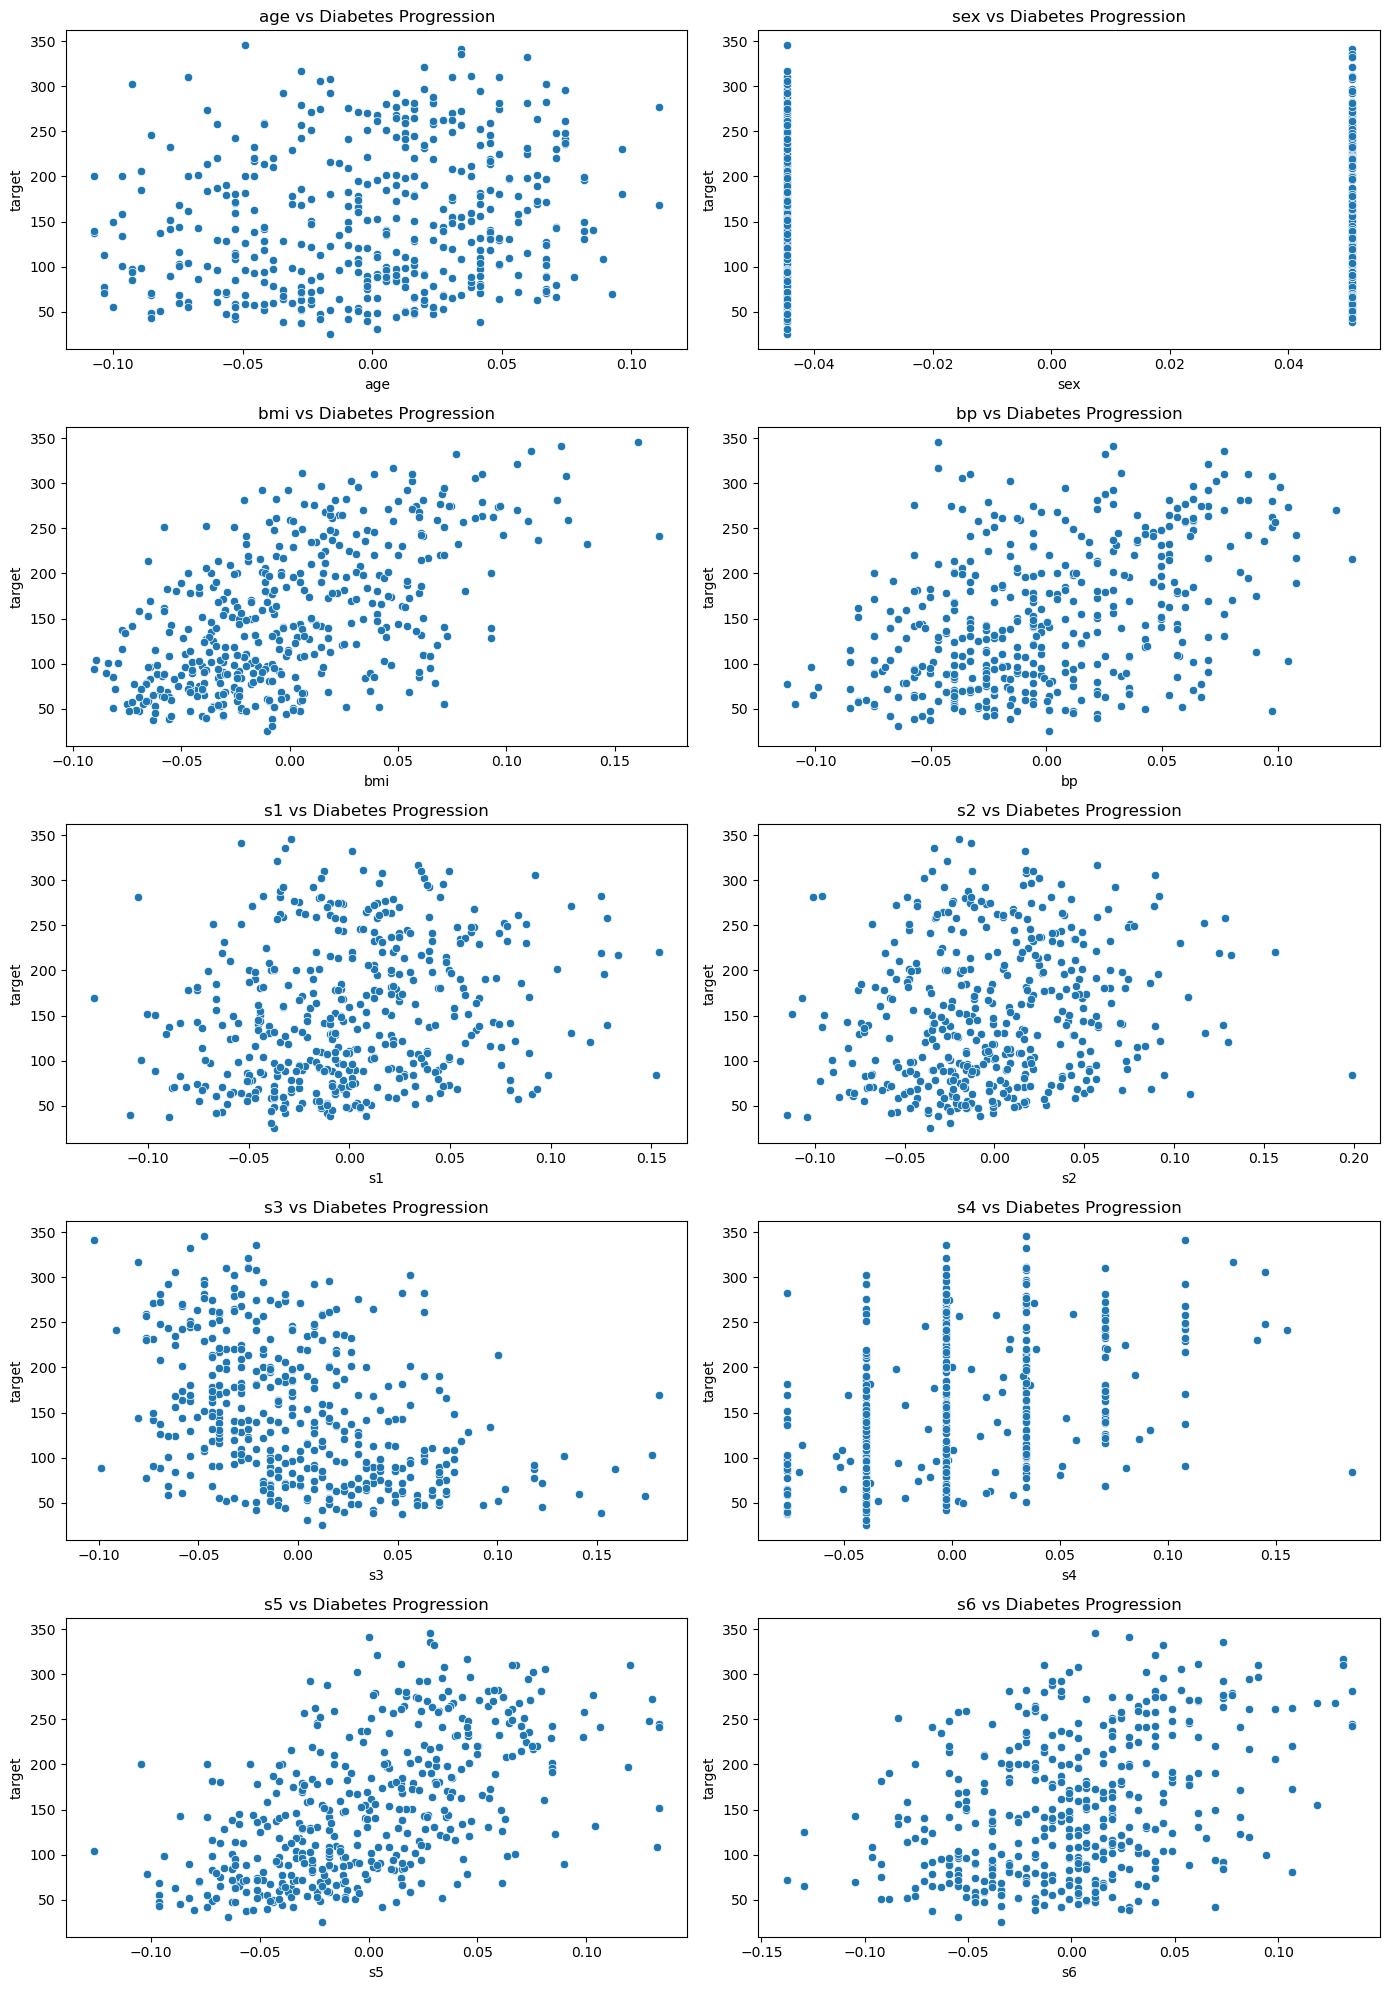

In [28]:
#Feature v/s Target relationships

features = diabetes.feature_names

fig, axes = plt.subplots(5, 2, figsize=(14, 20))

for i, feature in enumerate(features):
    row = i // 2
    col = i % 2
    
    sns.scatterplot(
        data=df,
        x=feature,
        y="target",
        ax=axes[row, col]
    )
    
    axes[row, col].set_title(f"{feature} vs Diabetes Progression")

plt.tight_layout()
plt.show()

In [29]:
#prepare data for ANN
#seperating features and target

X = df.drop("target", axis=1)
y = df["target"]

In [51]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


In [53]:
#Feature scaling usinng standard scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### **Model building**

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [59]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation="linear")
])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 32)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

#### **Model Compile**

In [60]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

#### **Train the ANN**

In [61]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 31223.8164 - mae: 157.7859 - val_loss: 22221.9727 - val_mae: 133.1551
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 31104.4434 - mae: 157.4264 - val_loss: 22132.9160 - val_mae: 132.8473
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 30970.1094 - mae: 157.0468 - val_loss: 22039.7227 - val_mae: 132.5215
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 30827.6055 - mae: 156.6342 - val_loss: 21938.5117 - val_mae: 132.1699
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 30666.1699 - mae: 156.1761 - val_loss: 21826.7441 - val_mae: 131.7844
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 30491.6133 - mae: 155.6769 - val_loss: 21701.5156 - val_mae: 131.3589
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 30291.3184 - mae: 155.1095 - val_loss: 21564.3047 - val_mae: 130.8896
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 30068.8965 - mae: 154.4809 - v

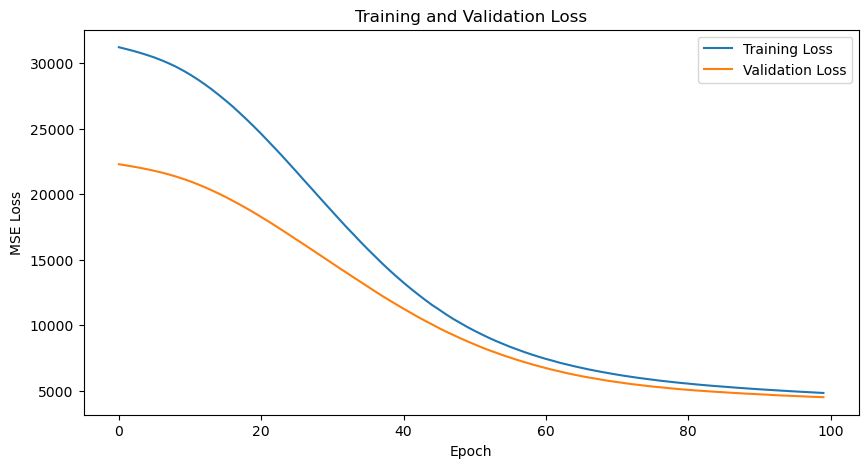

In [37]:
#Visualization of training and validation

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.show()

#### **Evaluate the Model**

In [41]:
#Import metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Mean Squared Error: 5266.89655234197
Root Mean Squared Error: 72.57338735612366
Mean Absolute Error: 56.53541724065716
R² Score: 0.00589926405625929


In [42]:
results = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R2 Score"],
    "Value": [mse, rmse, mae, r2]
})

results

,Metric,Value
0,MSE,5266.896552
1,RMSE,72.573387
2,MAE,56.535417
3,R2 Score,0.005899


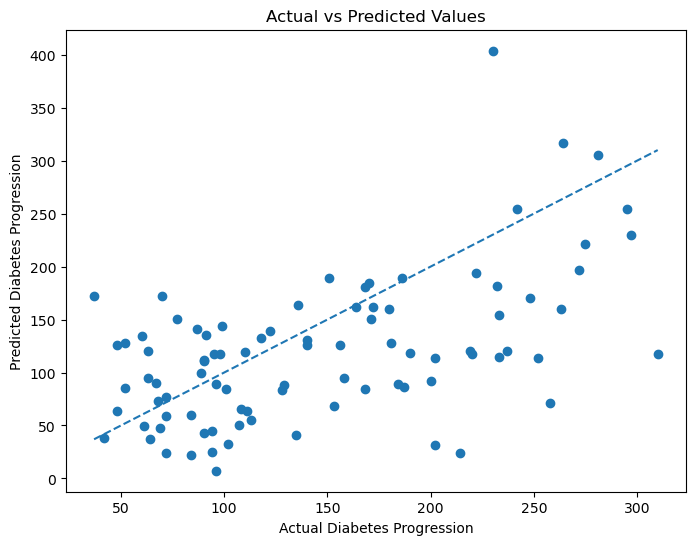

In [44]:
#Actual vs Predicted Values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Diabetes Progression")
plt.ylabel("Predicted Diabetes Progression")
plt.title("Actual vs Predicted Values")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

#### Improved ANN

In [48]:

improved_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="linear")
])

improved_model.summary()

C:\Users\athul\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile Improved Model

In [65]:
improved_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"]
)

#### **Train improved Model**

In [66]:
history_improved = improved_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=1
)

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 31552.7344 - mae: 158.7502 - val_loss: 22448.3555 - val_mae: 133.9733
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 31441.1484 - mae: 158.4220 - val_loss: 22363.8418 - val_mae: 133.6827
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 31298.4570 - mae: 158.0179 - val_loss: 22251.1504 - val_mae: 133.2967
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 31115.9180 - mae: 157.4848 - val_loss: 22077.8574 - val_mae: 132.7001
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 30848.8965 - mae: 156.7080 - val_loss: 21818.4375 - val_mae: 131.8055
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 30368.1602 - mae: 155.3047 - val_loss: 21423.3184 - val_mae: 130.4442
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 29749.1914 - mae: 153.5359 - val_loss: 20864.0820 - val_mae: 128.5214
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 28771.3828 - mae: 150.7141 - v

#### **Evaluate Improved Model**

In [68]:
y_pred_improved = improved_model.predict(X_test_scaled).flatten()

mse_improved = mean_squared_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mse_improved)
mae_improved = mean_absolute_error(y_test, y_pred_improved)
r2_improved = r2_score(y_test, y_pred_improved)

print("Improved Model Performance")
print("--------------------------")
print("MSE  :", mse_improved)
print("RMSE :", rmse_improved)
print("MAE  :", mae_improved)
print("R2   :", r2_improved)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Improved Model Performance
--------------------------
MSE  : 2842.641212254017
RMSE : 53.31642535142446
MAE  : 42.26571861009919
R2   : 0.46346549755772637


#### **Compare Both Models**

In [69]:
comparison = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R2 Score"],
    "Basic ANN": [mse, rmse, mae, r2],
    "Improved ANN": [
        mse_improved,
        rmse_improved,
        mae_improved,
        r2_improved
    ]
})

comparison

,Metric,Basic ANN,Improved ANN
0,MSE,5266.896552,2842.641212
1,RMSE,72.573387,53.316425
2,MAE,56.535417,42.265719
3,R2 Score,0.005899,0.463465


## Conclusion

In this project, an Artificial Neural Network (ANN) was developed to predict diabetes disease progression using the Diabetes dataset available in the Scikit-learn library. The dataset contained 442 observations and 10 independent variables. Initial data analysis confirmed that there were no missing values or duplicate records. Exploratory Data Analysis was performed using statistical summaries, feature distributions, correlation analysis, and feature-versus-target visualizations to understand the structure and relationships within the dataset.

The features were standardized before being provided to the neural network, which helped place the input variables on comparable scales. The dataset was divided into 80% training data and 20% testing data. The initial ANN consisted of one hidden layer with 32 neurons using the ReLU activation function and a linear output layer suitable for regression. The basic model produced an MSE of 5266.90, RMSE of 72.57, MAE of 56.54, and an R² score of 0.0059 on the test data.

To improve the model, a deeper ANN architecture was introduced with 64, 32, and 16 neurons across multiple hidden layers. ReLU activation was used in the hidden layers, a 20% dropout layer was added to help reduce overfitting, and the learning rate was reduced from 0.001 to 0.0005. The number of training epochs was also increased from 100 to 150.

The improved model showed a clear improvement in test performance. Its MSE decreased from 5266.90 to 2842.64, RMSE decreased from 72.57 to 53.32, and MAE decreased from 56.54 to 42.27. The R² score increased substantially from 0.0059 to 0.4635. These results demonstrate that the deeper architecture was able to learn more meaningful relationships between the input variables and diabetes progression than the initial ANN.

Although the improved ANN performed considerably better than the basic model, the R² score of 0.4635 indicates that the model explains approximately 46.3% of the variation in the unseen test data. Therefore, the model demonstrates useful predictive capability but still has considerable room for improvement. Further improvements could involve systematic hyperparameter tuning, different network architectures, regularization strategies, early stopping, or comparison with suitable traditional regression models.

Overall, the project successfully demonstrated the complete deep learning workflow, including data loading, preprocessing, exploratory data analysis, feature normalization, ANN construction, model training, evaluation, and iterative model improvement. The comparison between the two ANN architectures also demonstrated how architectural and hyperparameter changes can significantly influence regression performance.
